# 03- Feature selection

## Objectif
Sélectionner et justifier les variables importantes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

df = pd.read_csv("../01_Data/processed/churn_features.csv")

if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

X = df.drop(columns=["Churn"])
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [2]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numeric_cols)
])

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'avg_charge_per_tenure',
                                                   'has_fiber',
                                                   'is_month_to_month',
                                                   'has_online_security',
                                                   'has_tech_support'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [3]:
result = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
19,avg_charge_per_tenure,0.153100,0.015229
14,Contract,0.092884,0.014776
4,tenure,0.061763,0.009908
7,InternetService,0.047915,0.006970
17,MonthlyCharges,0.043662,0.011133
18,TotalCharges,0.040746,0.009199
21,is_month_to_month,0.032732,0.010201
11,TechSupport,0.021220,0.008175
8,OnlineSecurity,0.020588,0.007188
20,has_fiber,0.019271,0.007668


## Interprétation
La permutation importance indique les variables qui impactent le plus la performance du modèle.


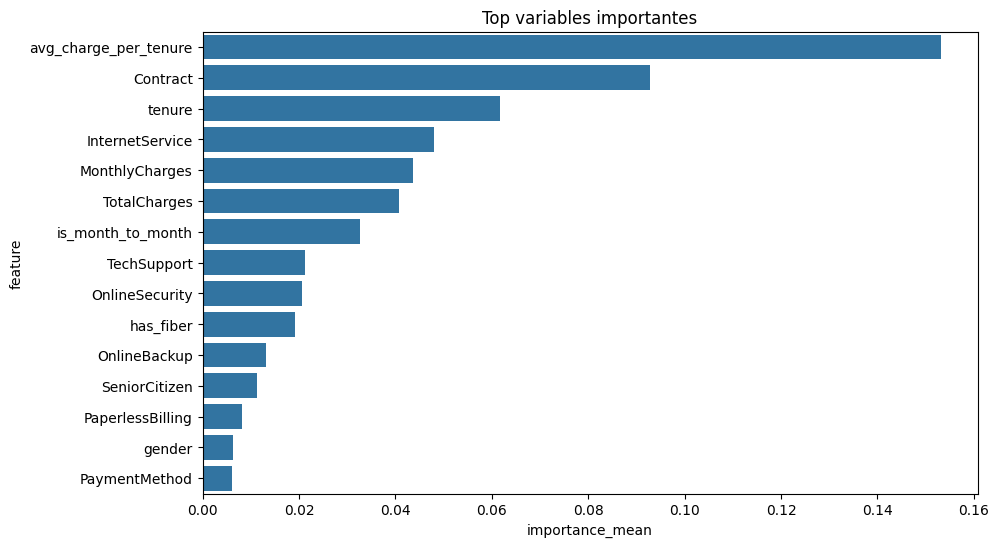

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance_mean", y="feature")
plt.title("Top variables importantes")
plt.show()

In [5]:
importance_df.to_csv("../01_Data/processed/feature_importance.csv", index=False)
print("Importance des variables sauvegardée.")

Importance des variables sauvegardée.
